In [110]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]


# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [111]:
import copy
from pathlib import Path

import pandas as pd

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}

for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]

        if len(df) == 525600:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


btc = coins_dict["BTCUSDT"]

HEDGE_LIST = {k: v for k, v in coins_dict.items() if k != "BTCUSDT"}


temp = copy.deepcopy(HEDGE_LIST)

Processing symbol: IMXUSDT, length: 525600
Processing symbol: SOLUSDT, length: 525600
Processing symbol: NOTUSDT, length: 525600
Processing symbol: BONKUSDT, length: 525600
Processing symbol: LTCUSDT, length: 525600
Processing symbol: ORDIUSDT, length: 525600
Processing symbol: SUIUSDT, length: 525600
Processing symbol: JUPUSDT, length: 525600
Processing symbol: NEARUSDT, length: 525600
Processing symbol: ATOMUSDT, length: 525600
Processing symbol: APTUSDT, length: 525600
Processing symbol: GALAUSDT, length: 525600
Processing symbol: ARBUSDT, length: 525600
Processing symbol: TRXUSDT, length: 525600
Processing symbol: BNBUSDT, length: 525600
Processing symbol: DOTUSDT, length: 525600
Processing symbol: FILUSDT, length: 525600
Processing symbol: ETCUSDT, length: 525600
Processing symbol: RENDERUSDT, length: 525600
Processing symbol: FLOKIUSDT, length: 525600
Processing symbol: BTCUSDT, length: 525600
Processing symbol: LINKUSDT, length: 525600
Processing symbol: SHIBUSDT, length: 525600

In [112]:
HEDGE_LIST = temp

In [113]:
from collections import deque

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linprog
from sklearn.linear_model import LinearRegression
from tqdm import tqdm

In [114]:
len(HEDGE_LIST.keys())

42

In [115]:
# 截取前半段（会真正修改 HEDGE_LIST 中的每个 DataFrame）
half_length = 525600 // 8

i = 3

for name, df in HEDGE_LIST.items():
    HEDGE_LIST[name] = df.iloc[(i - 1) * half_length : i * half_length]

btc = btc.iloc[(i - 1) * half_length : i * half_length]

In [116]:
BULLET_SIZE = 1000
INITIAL = 10000


FORWARD_WINDOW = 120
BACK_WINDOW = 360

MIN_POR = 0.05

In [117]:
back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


btc_close = deque(btc["Close"][:back_window], maxlen=back_window)
coin_closes = {
    name: deque(df["Close"][:back_window], maxlen=back_window)
    for name, df in HEDGE_LIST.items()
}

btc_volume = deque(btc["Volume"][:back_window], maxlen=back_window)
coin_volumes = {
    name: deque(df["Volume"][:back_window], maxlen=back_window)
    for name, df in HEDGE_LIST.items()
}

mkt_idx_1 = deque(np.array([0] * back_window), maxlen=back_window)
coin_vwaps = {
    name: deque(np.array([0] * back_window), maxlen=back_window)
    for name, df in HEDGE_LIST.items()
}

mkt_idx_2 = deque(np.array([0] * back_window), maxlen=back_window)

cmi_dict = {}


time_range = range(back_window, len(btc) - forward_window)

num = 0
revenues = []
stats = []


for i, t in tqdm(enumerate(time_range), total=len(time_range), desc="Sliding window"):
    btc_close.append(btc["Close"].iloc[t])
    btc_volume.append(btc["Volume"].iloc[t])

    if i >= back_window:
        vwap = np.sum(np.array(btc_close) * np.array(btc_volume)) / np.sum(
            np.array(btc_volume)
        )
        mkt_idx_1.append(vwap)
        mkt_idx_2.append(0)

    corr_array = []

    coef_records = {name: [] for name in HEDGE_LIST.keys()}

    for name, df in HEDGE_LIST.items():
        coin_closes[name].append(df["Close"].iloc[t])
        coin_volumes[name].append(df["Volume"].iloc[t])

        if i >= back_window:
            vwap = np.sum(
                np.array(coin_closes[name]) * np.array(coin_volumes[name])
            ) / np.sum(np.array(coin_volumes[name]))
            coin_vwaps[name].append(vwap)
            mkt_idx_2[-1] += np.sum(
                np.array(coin_closes[name]) * np.array(coin_volumes[name])
            )

    # if i%1000 ==0:
    #     plt.figure(figsize=(12, 6))
    #     ax1 = plt.subplot(3, 1, 1)
    #     ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    #     ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    #     ax1.plot(mkt_idx_1, label='Market Index 1 (VWAP)', color='blue')
    #     ax2.plot(mkt_idx_2, label='Market Index 2 (Volume Weighted Close)', color='orange')
    #     for name, vwap in coin_vwaps.items():
    #         normalized_vwap = np.array(vwap)/vwap[0]*100
    #         ax3.plot(normalized_vwap, label=f'{name} VWAP', alpha=0.3)
    #     ax1.set_title('Market Index 1 (VWAP)')
    #     ax2.set_title('Market Index 2 (Volume Weighted Close)')
    #     ax3.set_title('Coin VWAPs')
    #     plt.show()
    #     plt.close()

    mkt_idx_1_diff = np.diff(mkt_idx_1)
    mkt_idx_2_diff = np.diff(mkt_idx_2)

    # if i%1000 ==0:
    #     plt.figure(figsize=(12, 6))
    #     ax1 = plt.subplot(3, 1, 1)
    #     ax2 = plt.subplot(3, 1, 2, sharex=ax1)
    #     ax3 = plt.subplot(3, 1, 3, sharex=ax1)
    #     ax1.plot(mkt_idx_1_diff, label='Market Index 1 (VWAP)', color='blue')
    #     ax2.plot(mkt_idx_2_diff, label='Market Index 2 (Volume Weighted Close)', color='orange')
    #     for name, vwap in coin_vwaps.items():
    #         normalized_vwap = np.array(vwap)/vwap[0]*100
    #         ax3.plot(np.diff(normalized_vwap), label=f'{name} VWAP', alpha=0.3)
    #     ax1.set_title('Market Index 1 (VWAP)')
    #     ax2.set_title('Market Index 2 (Volume Weighted Close)')
    #     ax3.set_title('Coin VWAPs')
    #     plt.show()
    #     plt.close()

    if i >= back_window:
        for name, df in HEDGE_LIST.items():
            if i % forward_window == 0:
                # CMI
                arr = np.array(coin_closes[name]).reshape(-1, 1).flatten()

                diff = np.diff(arr)
                cmi = (arr[-1] - arr[0]) / np.sum(np.abs(diff)) * 100
                cmi_dict[name] = cmi

                coin_vwap_diff = np.diff(np.array(coin_vwaps[name]))

                # LINEAR
                y = np.array(coin_closes[name]).reshape(-1, 1)
                X_btc = np.array(btc_close).reshape(-1, 1)

                model_btc = LinearRegression(fit_intercept=True)
                model_btc.fit(X_btc, y)

                coef_btc = model_btc.coef_[0][0]

                y_pred_btc = model_btc.predict(X_btc)
                residual_btc = y - y_pred_btc

                # 计算收益率： r_t = p_t / p_{t-1} - 1
                y_ret = y[1:] / y[:-1] - 1
                x_ret = X_btc[1:] / X_btc[:-1] - 1

                # LINEAR 1
                y = np.array(coin_vwap_diff).reshape(-1, 1)
                X = np.array(mkt_idx_1_diff).reshape(-1, 1)

                model = LinearRegression(fit_intercept=True)
                model.fit(X, y)

                coef_1 = model.coef_[0][0]

                # LINEAR 2
                y = np.array(coin_vwap_diff).reshape(-1, 1)
                X = np.array(mkt_idx_2_diff).reshape(-1, 1)

                model = LinearRegression(fit_intercept=True)
                model.fit(X, y)

                coef_2 = model.coef_[0][0]

                # RETURN
                coef_records[name] = {
                    # 'coef': coef_btc,
                    "coef_1": coef_1 / coef_btc,
                    "coef_2": coef_2 / coef_btc,
                    "correlation": np.corrcoef(y_ret.flatten(), x_ret.flatten())[0, 1],
                    "residual": residual_btc[-1, 0] / coef_btc,
                    "cmi": cmi,
                }

        if i % forward_window == 0:
            # print(f"\n=== Step {i}: Coefficients collected for all coins ===")
            # === 将 coef_records 转为 DataFrame ===
            coef_df = pd.DataFrame.from_dict(coef_records, orient="index")  # index=coin

            # === 确保 residual 列是 float ===
            coef_df["residual"] = coef_df["residual"].astype(float)
            coef_df["cmi"] = coef_df["cmi"].astype(float)
            coef_df["correlation"] = coef_df["correlation"].astype(float)
            coef_df["coef_1"] = coef_df["coef_1"]
            coef_df["coef_2"] = coef_df["coef_2"]

            # print(coef_df)

            sharpe = coef_df["cmi"].mean() / coef_df["cmi"].std()

            k = 8

            # 按 correlation 降序取前 k 个
            topk_df = (
                coef_df.sort_values(by="correlation", ascending=False).iloc[:k].copy()
            )
            if len(topk_df) < k:
                print(f"Warning: only {len(topk_df)} coins available, k={k}")
            names = topk_df.index.tolist()

            residuals = topk_df["residual"].values.astype(float)  # shape (k,)
            coef1 = topk_df["coef_1"].values.astype(float)
            coef2 = topk_df["coef_2"].values.astype(float)

            prices = np.array(
                [HEDGE_LIST[n]["Close"].iloc[t] for n in names], dtype=float
            )

            c = residuals.copy()

            A_eq = np.vstack([coef1, coef2, prices])
            position = bullet_size  # 保留你原来的 position 定义
            b_eq = np.array([0.0, 0.0, position], dtype=float)

            # === 边界约束 ===
            # 不设置 MIN_POR，也不强制正负号，让优化器自由选择
            ABS_MAX = position * 10 / np.maximum(prices, 1e-6)
            bounds = [(-abs(m), abs(m)) for m in ABS_MAX]  # 给出合理上下界防止发散

            # 求解线性规划
            res = linprog(c=c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")

            if res.success:
                theta = res.x
                objective_value = (
                    -res.fun
                )  # 因为我们最小化 -residual，所以真实的 residual_sum = -res.fun
                # 构建结果 DataFrame
                df = pd.DataFrame(
                    {
                        "name": names,
                        "coef_1": coef1,
                        "coef_2": coef2,
                        "price": prices,
                        "correlation": topk_df["correlation"].values,
                        "residual": residuals,
                        "theta": theta,
                        "theta*residual": theta * residuals,
                        "theta*price": theta * prices,
                    }
                )
                # print(df)

                # if objective_value < -0: and min(df['correlation'])>0.6 and sharpe<0.5 and sharpe>-0.5:

                num += 1
                stats.append(df["correlation"].mean())

                corr_array = np.array(corr_array)

                stop_loss_ratio = 0.02  # 2% 止损比例
                revenue_path = np.zeros(forward_window)
                revenue = 0.0

                # === 构建逐步revenue序列 ===
                for idx, row in df.iterrows():
                    name = row["name"]
                    theta_value = row["theta"]
                    price = HEDGE_LIST[name]["Close"].iloc[t]

                    # 对应币种未来价格路径
                    future_prices = HEDGE_LIST[name]["Close"].iloc[
                        t : t + forward_window
                    ]
                    # 单币种逐步收益
                    future_revenues = (future_prices - price) * theta_value
                    # 累加到组合
                    revenue_path += future_revenues.values  # 确保是numpy array

                # === 遍历止损逻辑 ===
                stopped_revenue = revenue_path[-1]  # 默认没止损时最后一个
                for r in revenue_path:
                    if r < -bullet_size * stop_loss_ratio:
                        stopped_revenue = -bullet_size * stop_loss_ratio
                        break  # 触发止损
                else:
                    stopped_revenue = revenue_path[-1]  # 没触发止损

                revenues.append(stopped_revenue)
                print(f"🟢 Step {i}, cumulative {sum(revenues):.2f}")
            else:
                print("⚠️ 线性规划求解失败:", res.message)

Sliding window:   1%|          | 338/65220 [00:00<00:19, 3372.15it/s]

🟢 Step 360, cumulative -20.00
🟢 Step 480, cumulative -40.00
🟢 Step 600, cumulative -60.00


Sliding window:   1%|          | 676/65220 [00:01<01:59, 538.45it/s] 

🟢 Step 720, cumulative 180.36


Sliding window:   1%|▏         | 835/65220 [00:01<02:21, 456.04it/s]

...

🟢 Step 64920, cumulative 2985.75


Sliding window: 100%|█████████▉| 65094/65220 [03:21<00:00, 335.39it/s]

🟢 Step 65040, cumulative 2965.75


Sliding window: 100%|██████████| 65220/65220 [03:21<00:00, 323.78it/s]

🟢 Step 65160, cumulative 2945.75


In [118]:
# import matplotlib.pyplot as plt

# x = stats
# y = revenues

# plt.scatter(x, y, color='red', alpha=0.3)
# plt.xlabel("X values")
# plt.ylabel("Y values")
# plt.title("Scatter Plot of X vs Y")
# plt.grid(True)
# plt.show()


In [119]:
# revenues

In [120]:
# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd

# x = np.array(stats)
# y = np.array(revenues)

# # === 按百分比分箱 ===
# n_bins = 10
# quantiles = np.linspace(0, 1, n_bins + 1)
# bins = np.quantile(x, quantiles)  # 按x的分位数分箱

# # 为避免重复的边界（在x有重复值时）
# bins = np.unique(bins)

# bin_labels = pd.cut(x, bins=bins, include_lowest=True)
# bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
# bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

# # === 两个子图（不共享 y） ===
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# # 左边：散点图
# ax1.scatter(x, y, alpha=0.3, color='steelblue')
# ax1.set_xlabel("x")
# ax1.set_ylabel("y")
# ax1.set_title("Scatter Plot")
# ax1.grid(True, linestyle='--', alpha=0.5)

# # 右边：分箱均值图
# ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
# ax2.set_xlabel("x (quantile bins)")
# ax2.set_ylabel("Mean of y")
# ax2.set_title("Binned Mean by Percentile")
# ax2.grid(True, linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.show()


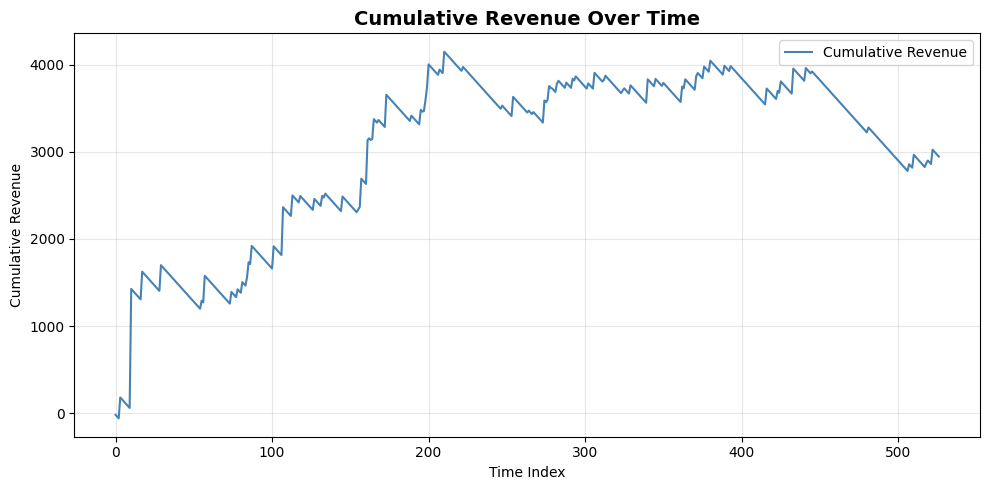

In [126]:
import numpy as np
import pandas as pd

# 假设 revenue_series 是 pandas Series 或 numpy array
# 示例：
revenue_series = pd.Series(revenues)

# 1️⃣ 累积收益
cumulative_revenue = np.cumsum(revenue_series)

# 2️⃣ 绘图
plt.figure(figsize=(10, 5))
plt.plot(
    cumulative_revenue, label="Cumulative Revenue", color="steelblue", linewidth=1.5
)
plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight="bold")
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_revenue.png", dpi=300)

In [125]:
revenue_series.describe()

count     527.000000
mean        5.589664
std        91.222394
min       -20.000000
25%       -20.000000
50%       -20.000000
75%       -20.000000
max      1365.838657
dtype: float64